# <center>AI1013: Programming for AI</center>
## <center>Assignment - 3</center>

### 1. Dataset Construction

#### Importing required modules

In [69]:
import numpy as np
import torch
from torch.nn.functional import relu
import matplotlib.pyplot as plt

Data Genearation

In [70]:
#1D input values
X = torch.linspace(-10,10,500)

#sin of X
sinX = torch.sin(X)

#calculating sinC
sinC = sinX / X

#if X==0, then sinc(X)=1, else sin(x) / x
sinC = torch.where(X==0, 1, sinC)

#adding gaussian noise (mean=0, var=0.01)
sinC_noisy = sinC + 0.1*torch.randn(sinC.shape)

#resizing for training the model
X = X.reshape(-1,1)
sinC_noisy = sinC_noisy.reshape(-1,1)

Visualisation

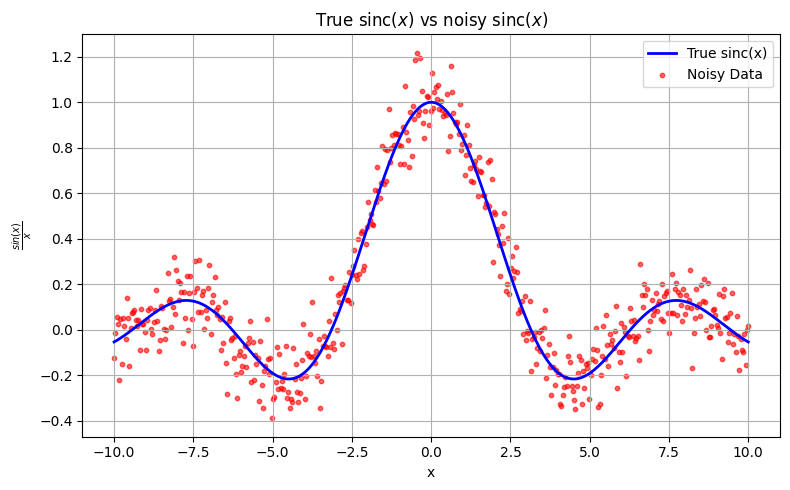

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(X, sinC, label='True sinc(x)', color='blue', linewidth=2)
plt.scatter(X, sinC_noisy, label='Noisy Data', color='red', s=10, alpha=0.6)

plt.title(r'True $\operatorname{sinc}(x)$ vs noisy $\operatorname{sinc}(x)$')
plt.xlabel('x')
plt.ylabel(r'$\frac{sin(x)}{x}$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 2.Multilayer Perceptron (MLP) with Two Hidden Layers

#### Model Architecure and setup

Defining MLP Model

In [72]:
class MLP(torch.nn.Module):
    def __init__(self, n_hidden1=3, n_hidden2=3):
        super(MLP, self).__init__()

        #linear layer(input (single number) -> n_hidden1)
        self.fc1 = torch.nn.Linear(1, n_hidden1)

        #linear layer (n_hidden1 -> n_hidden2)
        self.fc2 = torch.nn.Linear(n_hidden1, n_hidden2)

        #linear layer (n_hidden2 -> output (single number))
        self.fc3 = torch.nn.Linear(n_hidden2, 1)

    def forward(self,x):
        #pass to hidden layer1
        x = relu(self.fc1(x))

        #passing to hidden layer2
        x = relu(self.fc2(x))

        #passing to output
        x = self.fc3(x)

        return x

Hyperparameters setup

In [73]:
#creating our instance of MLP
model = MLP(40,40)

batch_size = 64
learning_rate = 0.02 #users choice
num_epochs = 100 # users choice


loss_function = torch.nn.MSELoss()


optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) #users choice

#### Trainig the MLP

Data Preparation

In [74]:
#wrapping the data in a dataset
dataset = torch.utils.data.TensorDataset(X, sinC_noisy)

#creating a dataloader
dataloader = torch.utils.data.DataLoader(dataset, shuffle=True, batch_size=batch_size)

Training Loop

In [75]:
training_loss = [] #to store losses and visualise later


#looping
for epoch in range(num_epochs):
    current_loss = 0.0

    for x,y in dataloader:
        #forward pass
        predicted = model(x)

        #calculating loss
        loss = loss_function(predicted, y)

        #going backward
        optimizer.zero_grad() #clear previous gradients if any
        loss.backward()
        optimizer.step()

        #keeping total loss
        current_loss += loss.item()

    training_loss.append(current_loss / len(dataloader))

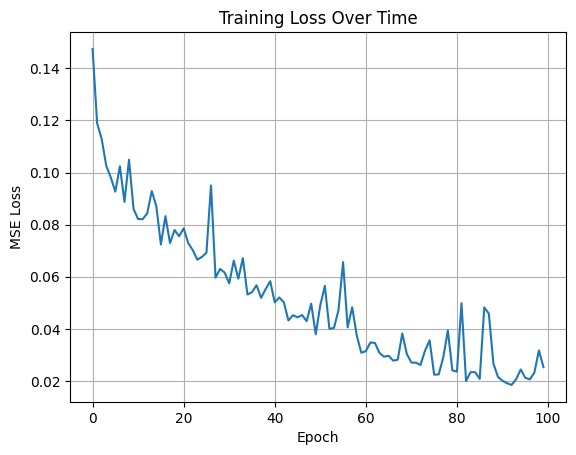

np.float64(0.0184952198760584)

In [76]:
plt.plot(training_loss)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()

np.array(training_loss).min()

#### Decision Boundary visualization

Generating a Mesh Grid

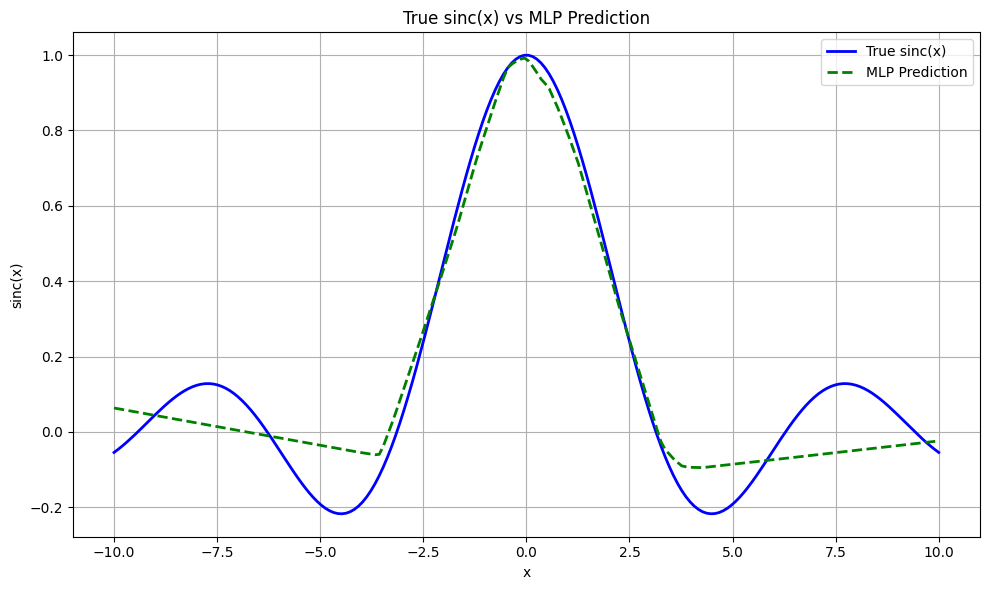

In [77]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Generate input grid (same as training range)
x_vals = np.linspace(-10, 10, 200)
X_grid = torch.tensor(x_vals, dtype=torch.float32).reshape(-1, 1)

# Compute true sinc values
true_sinc = torch.where(X_grid == 0, torch.tensor(1.0), torch.sin(X_grid) / X_grid)

# Predict using the trained model
model.eval()
with torch.no_grad():
    predicted_sinc = model(X_grid)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_vals, true_sinc.numpy(), label='True sinc(x)', color='blue', linewidth=2)
plt.plot(x_vals, predicted_sinc.numpy(), label='MLP Prediction', color='green', linestyle='--', linewidth=2)
plt.title("True sinc(x) vs MLP Prediction")
plt.xlabel("x")
plt.ylabel("sinc(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 3.Introduction to CNN

#### Data Preparation

Making the dataset class

In [78]:
import os
from PIL import Image
from torchvision import transforms

#defining the transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

class RPSDataset(torch.utils.data.Dataset):
    def __init__(self, img_folder):
        self.img_folder = img_folder
        self.classes = ["rock", "paper", "scissors"]
        self.labels = [] #it will have the label of each image
        self.img_paths =[] #it will have the img path for the corresponding image

        index=0 #for class index
        for classname in self.classes:
            #images are in folder named as "rock", "paper", "scissors"
            class_folder = os.path.join(self.img_folder, classname)

            #keeping a track of all images in this label
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                self.img_paths.append(img_path) #storing the path
                self.labels.append(index) #storing the label corresponding to current image

            index+=1 #next label

    #to get the image at a particular index
    def __getitem__(self, index):
        image_path, label = self.img_paths[index], self.labels[index]

        #opening
        image = Image.open(image_path).convert("RGB")

        #applying transform
        image_tensor = transform(image)


        return image_tensor, label


    #to get how many images we have
    def __len__(self):
        return len(self.labels)


Donwloading the dataset from kagglehub

In [79]:
# import kagglehub

# Download latest version
# path = kagglehub.dataset_downlo ad("drgfreeman/rockpaperscissors")

path = "./rps-cv-images"

print("Path to dataset files:", path)

Path to dataset files: ./rps-cv-images


Splitting the data into training and test sets

In [80]:
#creating an instance of our dataloader
import torch.utils.data.dataloader


dataset = RPSDataset(path)

#doing a 80-20 split
trainsize = int(0.8*len(dataset))
testsize = int(len(dataset) -trainsize)

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [trainsize, testsize])

#now we have our dataset split into train and test
#lets initialize dataloaders
batch_size = 32
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size= batch_size, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size= batch_size)

### Understanding Covolutions

creating the CNN Class for understanding

In [81]:
class CNN_learn(torch.nn.Module):
    def __init__(self, in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=1):
        super(CNN_learn, self).__init__()
        self.conv = torch.nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding)

    def forward(self, x):
        return self.conv(x)

We have defined our class, lets play around with it.

First, let's define the kernels that we are going to use

In [82]:
#defining our kernels
blur_kernel = torch.tensor([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)

edge_kernel = torch.tensor([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)


sharpen_kernel = torch.tensor([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)

kernels = [blur_kernel, edge_kernel, sharpen_kernel]
kernel_names = ["Blur", "Edge", "Sharpen"]

Lets select a image and check the input and output dimensions

In [83]:

#selecting a image
image_path = path + "/paper/4Fxr7klOIfijCpio.png"

#opening
image = Image.open(image_path).convert("RGB")

#applying transform
image_tensor = transform(image).unsqueeze(0)

print("Input shape : ", image_tensor.size())
model = CNN_learn(in_channels=3, out_channels=1, kernel_size=3, padding=1,stride=1)
output = model(image_tensor)
print("Output shape : ", output.size())

Input shape :  torch.Size([1, 3, 224, 224])
Output shape :  torch.Size([1, 1, 224, 224])


The input shape and output shape do match. Since we are using padding=1, and strid =1, the original dimension of the image is preserved. Also, in_channels = 3, but out_channels = 1 is also visible from the output.

Let's now apply different kernels and visualize the feature maps

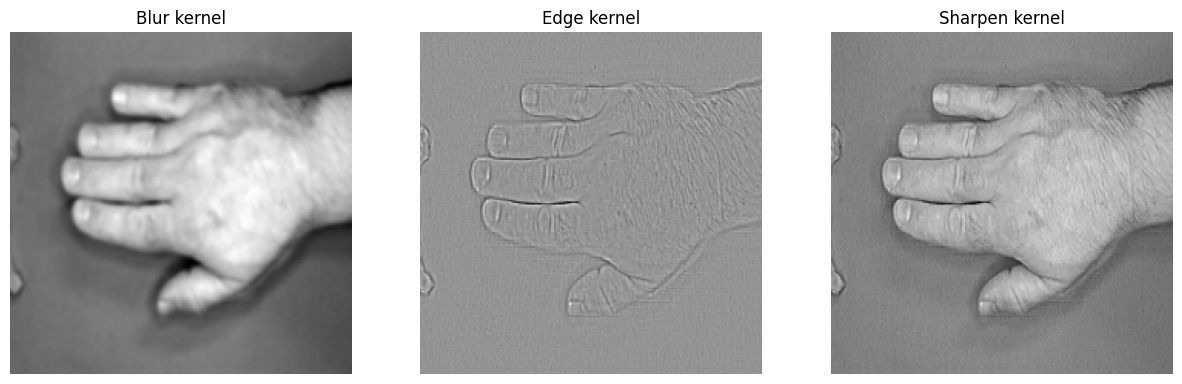

In [84]:
fig_basic, axes_basic = plt.subplots(1,3,figsize=(15,5))
for i in range(3):
    model = CNN_learn(in_channels=3, out_channels=1, kernel_size=3, padding=0,stride=1)
    with torch.no_grad():
        model.conv.weight.copy_(kernels[i])

    #applying convolution
    output = model(image_tensor)
    feature_map = output.squeeze(0)
    feature_map_permuted = feature_map.permute(1,2,0).detach().numpy()

    axes_basic[i].imshow(feature_map_permuted, cmap="gray")
    axes_basic[i].axis('off')
    axes_basic[i].set_title(kernel_names[i]+" kernel")

This is self-explanatory, lets try to modify padding, stride and kernel_size and see how it works

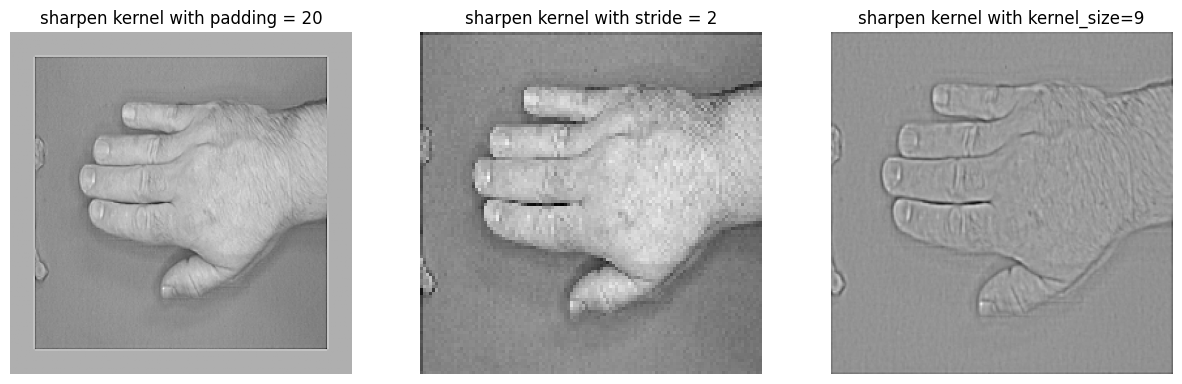

In [85]:
figs_modified_params, axes_modified_params = plt.subplots(1,3, figsize=(15,5))

###########################
###padding modificiation###
###########################
model = CNN_learn(in_channels=3, out_channels=1, kernel_size=3, padding=20,stride=1)
with torch.no_grad():
    model.conv.weight.copy_(kernels[i])

#applying convolution
output = model(image_tensor)
feature_map = output.squeeze(0)
feature_map_permuted = feature_map.permute(1,2,0).detach().numpy()

axes_modified_params[0].imshow(feature_map_permuted, cmap="gray")
axes_modified_params[0].axis('off')
axes_modified_params[0].set_title("sharpen kernel with padding = 20")

###########################
####stride modification####
###########################
model = CNN_learn(in_channels=3, out_channels=1, kernel_size=3, padding=1,stride=2)
with torch.no_grad():
    model.conv.weight.copy_(kernels[i])

#applying convolution
output = model(image_tensor)
feature_map = output.squeeze(0)
feature_map_permuted = feature_map.permute(1,2,0).detach().numpy()

axes_modified_params[1].imshow(feature_map_permuted, cmap="gray")
axes_modified_params[1].axis('off')
axes_modified_params[1].set_title("sharpen kernel with stride = 2")

###########################
####kernel modification####
###########################
model = CNN_learn(in_channels=3, out_channels=1, kernel_size=5, padding=1,stride=1)

#making the kernels
sharpen_kernel_5ks = -1 * torch.ones((5, 5))
sharpen_kernel_5ks[2, 2] = 25

blur_kernel_5ks = torch.ones((5,5)) / (25)

edge_kernel_5ks = -1 * torch.ones((5, 5))
edge_kernel_5ks[2, 2] = 24

#aaplying the kernel
with torch.no_grad():
    model.conv.weight.copy_(sharpen_kernel_5ks)


#applying convolution
output = model(image_tensor)
feature_map = output.squeeze(0)
feature_map_permuted = feature_map.permute(1,2,0).detach().numpy()

axes_modified_params[2].imshow(feature_map_permuted, cmap="gray")
axes_modified_params[2].axis('off')
axes_modified_params[2].set_title("sharpen kernel with kernel_size=9")

plt.show()

The image outputs help us visualise how does these parameters work. \
Increasing the padding helps the model to easily work with the edge pixels. \
Increasing the stride reduces the feture map's quality, as it skips more pixels. \
Increasing the kernel size, increases the effect of kernel, like making it more sharp or more blurry.

### Pooling Functions

Creating a CNN class with pooling layer

In [86]:
class CNN_pool(torch.nn.Module):
    def __init__(self, in_channels=3, out_channels=1, kernel_size=3, stride=1, padding=1, pool_kernel=2):
        super(CNN_pool, self).__init__()
        self.conv = torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.pool = torch.nn.MaxPool2d(pool_kernel)

    def forward(self, x):
        feature_map_before = self.conv(x)
        feature_map_after = self.pool(feature_map_before)
        return feature_map_before, feature_map_after

Now lets verify the output dimensions.

In [87]:
model = CNN_pool(in_channels=3, out_channels=1, kernel_size=3, padding=1,stride=1, pool_kernel=2)
output_before, output_after = model(image_tensor)
print("Input shape : ", image_tensor.size())
print("Output shape (before pooling) : ", output_before.size())
print("Output shape (after pooling) : ", output_after.size())

Input shape :  torch.Size([1, 3, 224, 224])
Output shape (before pooling) :  torch.Size([1, 1, 224, 224])
Output shape (after pooling) :  torch.Size([1, 1, 112, 112])


The dimensions come out to be as expected. The input and output (before pooling) have same dimensions (only no. of channel is different). But after applying the pooling, the height and the width of the image get halved as expected.

Lets now compare the features maps before and after maxpooling.

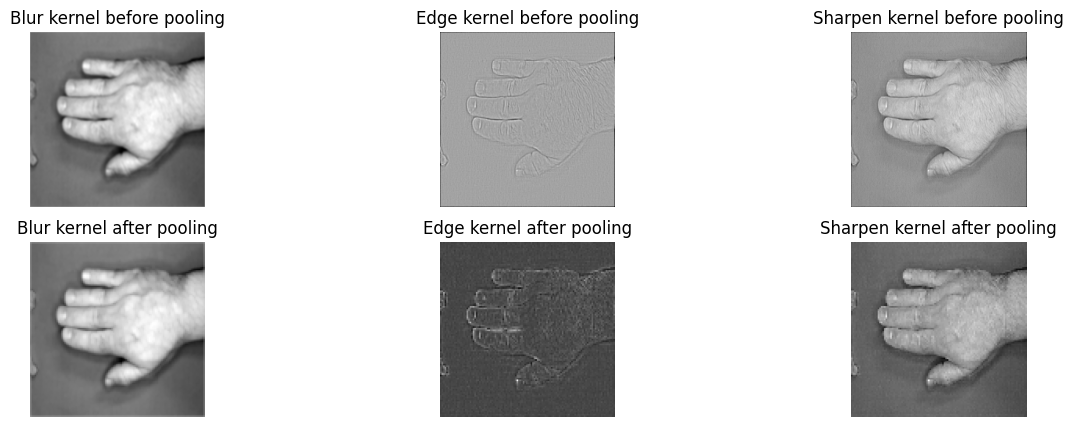

In [88]:
fig_pooling, axes_pooling = plt.subplots(2,3,figsize=(15,5))
for i in range(3):
    model = CNN_pool(in_channels=3, out_channels=1, kernel_size=3, padding=1,stride=1, pool_kernel=2)
    with torch.no_grad():
        model.conv.weight.copy_(kernels[i])

    #applying convolution
    output_before, output_after = model(image_tensor)
    feature_map_before, feature_map_after = output_before.squeeze(0), output_after.squeeze(0)
    feature_map_permuted_before = feature_map_before.permute(1,2,0).detach().numpy()
    feature_map_permuted_after = feature_map_after.permute(1,2,0).detach().numpy()

    #plotting feature maps
    axes_pooling[0][i].imshow(feature_map_permuted_before, cmap="gray")
    axes_pooling[0][i].axis('off')
    axes_pooling[0][i].set_title(kernel_names[i]+" kernel before pooling")

    axes_pooling[1][i].imshow(feature_map_permuted_after, cmap="gray")
    axes_pooling[1][i].axis('off')
    axes_pooling[1][i].set_title(kernel_names[i]+" kernel after pooling")

We observe that on applying pooling, the image loses dimension, but retains the details it had.

Let's now implement a class with GAP Layer and verify the output shape

In [89]:
class CNN_GAP(torch.nn.Module):
    def __init__(self, in_channels=3, out_channels=1, kernel_size=3, stride=1, padding=1):
        super(CNN_GAP, self).__init__()
        self.conv = torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.gap = torch.nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
      output_before = self.conv(x)
      output_after = self.gap(output_before)
      return output_before, output_after

Let's verify the output dimensions.

In [90]:
model= CNN_GAP(in_channels=3, out_channels=1, kernel_size=3, padding=1,stride=1)
output_before, output_after = model(image_tensor)
print("Input shape : ", image_tensor.size())
print("Output shape (before GAP) : ", output_before.size())
print("Output shape (after GAP) : ", output_after.size())

Input shape :  torch.Size([1, 3, 224, 224])
Output shape (before GAP) :  torch.Size([1, 1, 224, 224])
Output shape (after GAP) :  torch.Size([1, 1, 1, 1])


The dimensions after GAP comes out as expected. Our image of dimension 200x300 has been compressed to a single number (dim 1x1)

### Building the complete CNN Model

Implementing the CNN class.

In [91]:
class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.relu = torch.nn.ReLU()

        #layer1
        self.conv1 = torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        #layer2
        self.conv2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        #layer3
        self.conv3 = torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool3 = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        #gap
        self.gap = torch.nn.AdaptiveAvgPool2d((1, 1))

        #input to hidden layer
        self.fc1 = torch.nn.Linear(64,32)

        #from hidden layer to output (3 classes)
        self.fc2 = torch.nn.Linear(32,3)

        self.softmax = torch.nn.Softmax(dim=1)

    def forward(self,x):
        #layer1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        #layer2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)

        #layer3
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool3(x)

        #gap
        x = self.gap(x)
        x = x.view(x.size(0), -1)

        #input to hidden layer
        x = self.fc1(x)

        #from hidden layer to output (3 classes)
        x = self.fc2(x)

        return x

    def print_shapes(self, x):
        print("Input shape : ", x.size())

        x = self.conv1(x)
        print("After Layer1 convolution : ", x.size())

        x = self.relu(x)
        print("After Layer1 ReLU : ", x.size())

        x = self.pool1(x)
        print("After Layer1 pooling : ", x.size())

        x = self.conv2(x)
        print("After Layer2 convolution : ", x.size())

        x = self.relu(x)
        print("After Layer2 ReLU : ", x.size())

        x = self.pool2(x)
        print("After Layer2 pooling : ", x.size())

        x = self.conv3(x)
        print("After Layer3 convolution : ", x.size())

        x = self.relu(x)
        print("After Layer3 ReLU : ", x.size())

        x = self.pool3(x)
        print("After Layer3 pooling : ", x.size())

        x = self.gap(x)
        print("After GAP : ", x.size())

        x = x.view(x.size(0), -1)
        print("After flattening : ", x.size())

        x = self.fc1(x)
        print("After input to hidden layer : ", x.size())

        x = self.fc2(x)
        print("After hidden to output layer : ", x.size())

        x = self.softmax(x)
        print("After softmax : ", x.size())




We're done with the class implementation.

Let's now print the shapes.

In [92]:
model = CNN()

model.print_shapes(image_tensor)

Input shape :  torch.Size([1, 3, 224, 224])
After Layer1 convolution :  torch.Size([1, 16, 224, 224])
After Layer1 ReLU :  torch.Size([1, 16, 224, 224])
After Layer1 pooling :  torch.Size([1, 16, 112, 112])
After Layer2 convolution :  torch.Size([1, 32, 112, 112])
After Layer2 ReLU :  torch.Size([1, 32, 112, 112])
After Layer2 pooling :  torch.Size([1, 32, 56, 56])
After Layer3 convolution :  torch.Size([1, 64, 56, 56])
After Layer3 ReLU :  torch.Size([1, 64, 56, 56])
After Layer3 pooling :  torch.Size([1, 64, 28, 28])
After GAP :  torch.Size([1, 64, 1, 1])
After flattening :  torch.Size([1, 64])
After input to hidden layer :  torch.Size([1, 32])
After hidden to output layer :  torch.Size([1, 3])
After softmax :  torch.Size([1, 3])


The input, output and the intermediaey shapes are all as per expectation. The final output is of size 3.

### Training and Evaluation

lets set the optimizer and the loss function.

In [ ]:
model = CNN()

#moving to GPU
device = torch.device("mps" if torch.mps.is_available() else "cpu")
model = model.to(device)
print("Using device ", device)

loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

#lists to store training and test accuracy
train_accuracies = []
test_accuracies = []

num_epochs = 50

for epoch in range(num_epochs):
    #put model into trainig mode
    model.train()

    #to calculate accuracy in this epoch
    correct = 0
    total = 0


    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        #forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        # print(outputs[0])
        # print(labels[0])
        loss = loss_function(outputs, labels)

        #backward pass
        loss.backward()
        optimizer.step()

        # for name, param in model.named_parameters():
        #     if param.grad is not None:
        #         print(f"{name} grad mean: {param.grad.abs().mean().item():.6f}")


        #for accuracy
        temp, predicted = torch.max(outputs,1)
        correct+= (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracies.append(100*correct/total)

    #evaluating
    model.eval()
    correct = 0
    total= 0

    #no need of gradients
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            #accuracy calculation
            temp, predicted = torch.max(outputs,1)
            correct+= (predicted == labels).sum().item()
            total += labels.size(0)

    test_accuracies.append(100*correct/total)

    #lets print this epochs stats
    print(f"Epoch {epoch+1} : train_accuracy = {train_accuracies[-1]}%, test_accuracy = {test_accuracies[-1]}%")

    

Using device  mps


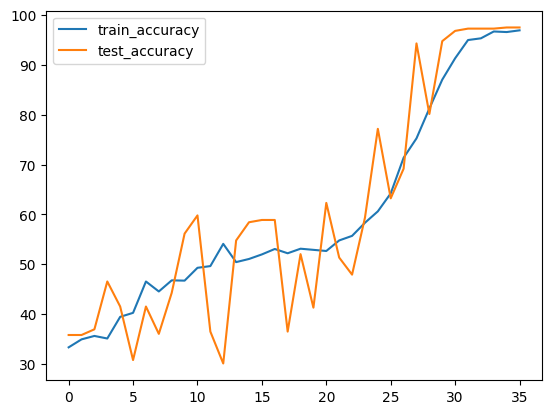

In [95]:
plt.plot(train_accuracies, label="train_accuracy")
plt.plot(test_accuracies, label="test_accuracy")
plt.legend()
plt.show()